# Общая информация по лабораторным работам

Задания выполняются по предложенному шаблону и методическим указаниям.

Методические указания к лабораторным работам:

*   [Савва Т.Ю. Методы машинного обучения:
методические указания к лабораторным работам (2018).](https://www.irsit.ru/lit/75383.pdf)

ПО на выбор:
* Google Colab.
* [Jupyter Notebook](https://practicum.yandex.ru/blog/chto-takoe-jupyter-notebook/).
* Anaconda / IDE с плагинами/поддержкой Jupyter Notebook.

Рекомендованные источники:
* [Курс К.В.Воронцова по машинному обучению.](http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_(%D0%BA%D1%83%D1%80%D1%81_%D0%BB%D0%B5%D0%BA%D1%86%D0%B8%D0%B9,_%D0%9A.%D0%92.%D0%92%D0%BE%D1%80%D0%BE%D0%BD%D1%86%D0%BE%D0%B2))
* [Онлайн-учебник по ML от Школы Анализа Данных (ШАД) Яндекса.](https://education.yandex.ru/handbook/ml)
* Плас Дж. Вандер. Python для сложных задач - наука о данных и машинное обучение / [Jake VanderPlas. Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) (второе издание, 2023).
* Уэс Маккинни. Python и анализ данных / [Wes McKinney. Python for Data Analysis](https://wesmckinney.com/book/) (третье издание, 2023).



# ЛР №1. Предобработка данных и проектирование признаков.<br>ЛР № 2. Визуализация зависимостей целевой переменной от входных признаков

## I. Практикум.
Семинары ИСП РАН из курса по ML (весна 2025).
*   [Pandas. Numpy.](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/seminars/seminar1/01_numpy_pandas_student.ipynb)
*   [Обработка данных.](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/seminars/seminar2/02_data_processing_student.ipynb)



## II. Основы анализа данных на языке Python. Предобработка данных и проектирование признаков. Визуализация зависимостей целевой переменной от входных признаков.

Выполните задания к 1, 2 и 3 лабораторным работам из методички, используя предложенный набор данных со сведениями о пассажирах "Титаника", доступный в соревновании на платформе Kaggle.

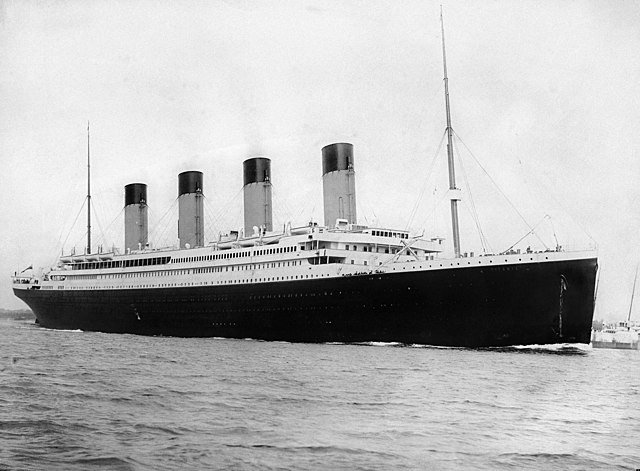

[*Источник*](https://ru.wikipedia.org/wiki/%D0%A2%D0%B8%D1%82%D0%B0%D0%BD%D0%B8%D0%BA#/media/%D0%A4%D0%B0%D0%B9%D0%BB:RMS_Titanic_3.jpg)



Описание данных:
* `PassengerId`: идентификатор пассжира.
* `Survived`: выжил ли пассажир (1) или нет (0).
* `Pclass`: класс билета (от первого класса до третьего).
* `Name`: имя пассажира. Имя также может содержать титулы и обращения.
* `Sex`: пол.
* `Age`: возраст в годах.
* `SibSp`: Количество братьев или сестер / супругов на борту.
* `Parch`: Количество родителей / детей на борту.
* `Ticket`: номер билета.
* `Fare`: сумма, которую заплатил пассажир за путешествие.
* `Cabin`: номер каюты.
* `Embarked`: порт отправления.

### 1. Загрузка библиотек: NumPy, Pandas, Scikit-learn (sklearn) и Matplotlib (+ Seaborn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk


### 2. Загрузка датасета.

"Титаник" в [открытом доступе](https://github.com/josem279/titanic_dataset).

In [2]:
df_train = pd.read_csv('https://raw.githubusercontent.com/josem279/titanic_dataset/refs/heads/main/data/train.csv')

### 3. Анализ исходной выборки (датасета). Получение статистических данных.

* Как выглядит датасет. Целевая переменная и признаки объектов.
* Размер датасета.
* Статистическая информация. Типы признаков.
* Преобразование категориальных признаков к категориальному типу данных.
* Пропуски и дубликаты.



In [ ]:
print("Первые 5 строк обучающей выборки:")
display(df_train.head())


print("\nПризнаки (колонки) объектов:")
print(df_train.columns.tolist())

print("\nЦелевая переменная: Survived (выжил/не выжил)")

print(f"\nРазмер обучающей выборки (train): {df_train.shape[0]} строк, {df_train.shape[1]} столбцов")

print("Типы признаков в датасете:")
display(df_train.dtypes.to_frame(name='Тип данных'))

print("\nСтатистическая информация (числовые признаки):")
display(df_train.describe())

print("\nСтатистическая информация (строковые и категориальные признаки):")
display(df_train.describe(include=['object', 'category']))

cat_columns = ['Survived', 'Sex', 'Embarked', 'Pclass']

# Преобразуем типы в обучающей и тестовой выборках
for col in cat_columns:
    df_train[col] = df_train[col].astype('category')

print("Типы признаков после преобразования:")
display(df_train[cat_columns].dtypes.to_frame(name='Новый тип данных'))

print("Количество пропусков по признакам (train):")
missing_train = df_train.isnull().sum()
display(missing_train[missing_train > 0].to_frame(name='Количество пропусков'))

print(f"Полные дубликаты пассажиров: {df_train.duplicated().sum()}")
print(f"Дубликаты по Имени (Name): {df_train.duplicated(subset=['Name']).sum()}")
print(f"Дубликаты по Номеру билета (Ticket): {df_train.duplicated(subset=['Ticket']).sum()} (означает, что люди ехали по одному билету)")
print(f"Дубликаты по Номеру каюты (Cabin): {df_train.duplicated(subset=['Cabin']).sum()}")
print(f"Дубликаты по Порту отправления (Embarked): {df_train.duplicated(subset=['Embarked']).sum()}")

Первые 5 строк обучающей выборки:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Признаки (колонки) объектов:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Целевая переменная: Survived (выжил/не выжил)

Размер обучающей выборки (train): 891 строк, 12 столбцов
Типы признаков в датасете:


,Тип данных
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Статистическая информация (числовые признаки):


...

Типы признаков после преобразования:


,Новый тип данных
Survived,category
Sex,category
Embarked,category
Pclass,category


Количество пропусков по признакам (train):


,Количество пропусков
Age,177
Cabin,687
Embarked,2


Полные дубликаты пассажиров: 0
Дубликаты по Имени (Name): 0
Дубликаты по Номеру билета (Ticket): 210 (означает, что люди ехали по одному билету)
Дубликаты по Номеру каюты (Cabin): 743
Дубликаты по Порту отправления (Embarked): 887


### 4. Очистка данных. Отсутствующие значения.

*Советы:*
* самое очевидное решение может быть не самым лучшим;
* между признаками могут существовать более сложные зависимости, чем кажется на первый взгляд.



In [4]:
# Извлекаем титулы из имен пассажиров
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)

# Смотрим, какие титулы есть и сколько в них пропусков возраста
print("Медианный возраст по титулам:")
title_age_medians = df_train.groupby('Title')['Age'].median()
display(title_age_medians.to_frame().T)

# Заполняем пропуски Возраста медианой соответствующего титула
df_train['Age'] = df_train['Age'].fillna(df_train['Title'].map(title_age_medians))

# На всякий случай (если останутся пропуски у редких титулов), заполняем общей медианой
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

df_train['Cabin'] = df_train['Cabin'].fillna(0)

# Находим самый частый порт посадки (моду)
most_frequent_port = df_train['Embarked'].mode()[0]
# Заполняем пропуски
df_train['Embarked'] = df_train['Embarked'].fillna(most_frequent_port)

Медианный возраст по титулам:


Title,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Age,70.0,58.0,33.0,40.0,46.5,38.0,48.0,48.5,3.5,21.0,24.0,24.0,30.0,35.0,28.0,46.5,49.0


### 5. Зависимости между признаками.

* Совместное распределение между признаками (сводные таблицы).
* [pandas.DataFrame.corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) + визуализация: тепловая карта (Heat map).
* Диаграммы рассеяния для пар признаков.



,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000000,-0.354005,0.083081,0.018443,-0.549500
Age,-0.354005,1.000000,-0.265602,-0.188122,0.097944
SibSp,0.083081,-0.265602,1.000000,0.414838,0.159651
Parch,0.018443,-0.188122,0.414838,1.000000,0.216225
Fare,-0.549500,0.097944,0.159651,0.216225,1.000000


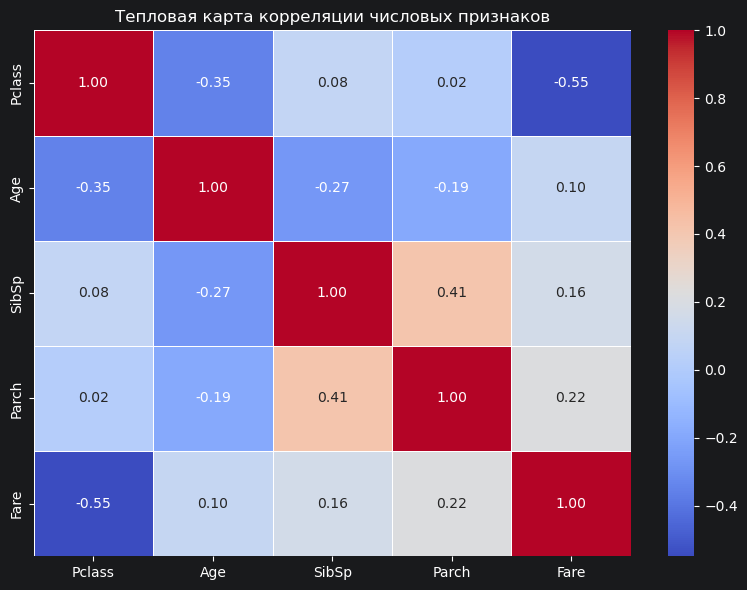

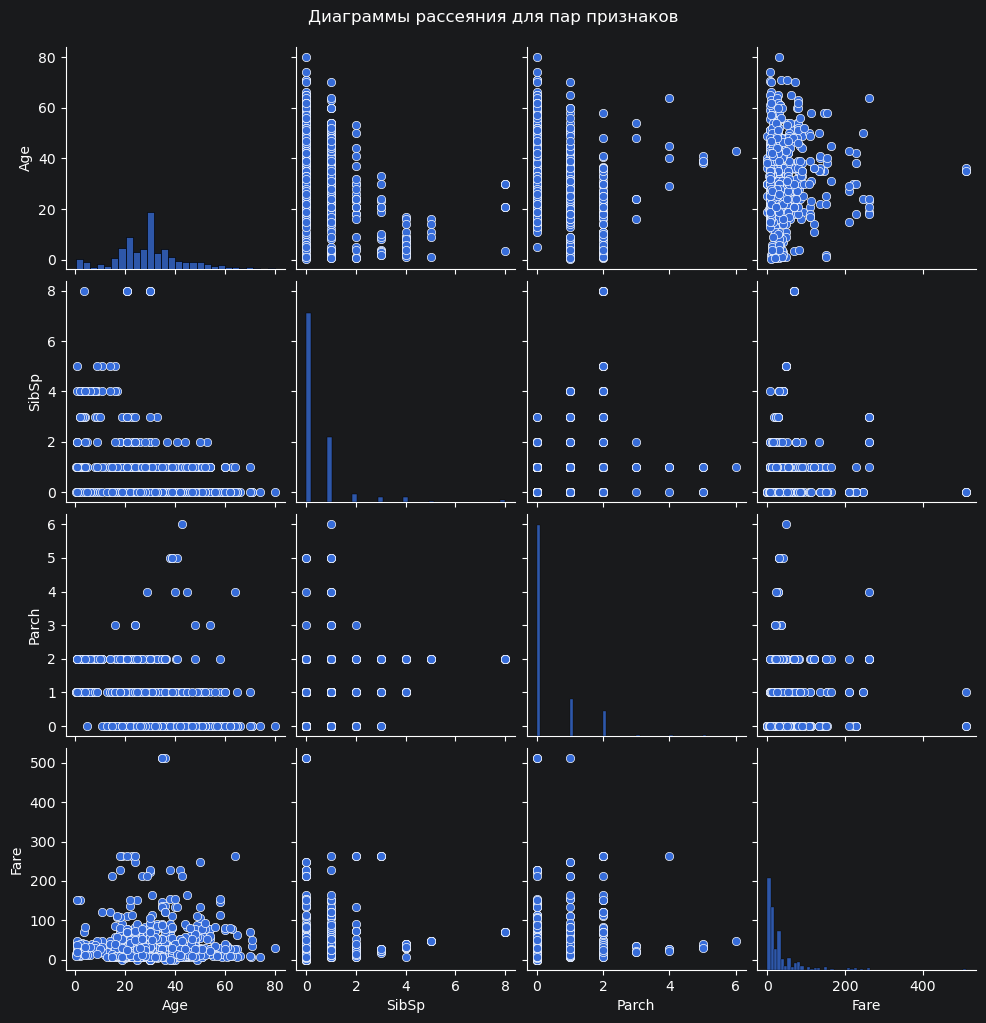

In [8]:
corr_matrix = df_train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Тепловая карта корреляции числовых признаков")
plt.tight_layout()
plt.show()

sns.pairplot(df_train[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']])
plt.suptitle("Диаграммы рассеяния для пар признаков", y=1.02)
plt.show()

### 6. Кодирование признаков.

*   Кодирование категориальных признаков.
*   Кодирование нечисловых признаков.




In [9]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding для бинарного признака Sex
le = LabelEncoder()
df_train['Sex_encoded'] = le.fit_transform(df_train['Sex'])

# One-Hot Encoding для Embarked (3 категории)
df_train = pd.get_dummies(df_train, columns=['Embarked'], prefix='Embarked', drop_first=False)

# Pclass уже числовой (1/2/3), оставляем как есть
# Cabin: извлекаем первую букву (палубу) и кодируем
df_train['Deck'] = df_train['Cabin'].str[0]
df_train['Deck_encoded'] = LabelEncoder().fit_transform(df_train['Deck'])

print("Пример закодированных признаков:")
display(df_train[['Sex', 'Sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Deck', 'Deck_encoded']].head())

Пример закодированных признаков:


,Sex,Sex_encoded,Embarked_C,Embarked_Q,Embarked_S,Deck,Deck_encoded
0,male,1,False,False,True,NaN,8
1,female,0,True,False,False,C,2
2,female,0,False,False,True,NaN,8
3,female,0,False,False,True,C,2
4,male,1,False,False,True,NaN,8


### 7. Проектирование признаков (как минимум для одного признака исходного набора данных).

*Советы:*
* имеющийся признак может содержать в себе дополнительную информацию;
* новый признак может представлять собой функцию от нескольких имеющихся признаков;
* некоторые признаки может быть полезным преобразовать: например, непрерывный признак - в дискретный (binning).



In [10]:
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master'
}
df_train['Title_grouped'] = df_train['Title'].map(title_mapping).fillna('Other')
df_train['Title_encoded'] = LabelEncoder().fit_transform(df_train['Title_grouped'])

# 2. Размер семьи: SibSp + Parch + сам пассажир
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1

# 3. Одиночка: 1, если едет один
df_train['IsAlone'] = (df_train['FamilySize'] == 1).astype(int)

# 4. Возрастные группы (binning)
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df_train['AgeGroup'] = pd.cut(df_train['Age'], bins=bins, labels=labels)
df_train['AgeGroup_encoded'] = LabelEncoder().fit_transform(df_train['AgeGroup'].astype(str))

print("Новые признаки:")
display(df_train[['FamilySize', 'IsAlone', 'Title_grouped', 'AgeGroup']].head(10))
# TODO: проверить, как влияет удаление FamilySize или IsAlone во 2-й лабораторной

Новые признаки:


,FamilySize,IsAlone,Title_grouped,AgeGroup
0,2,0,Mr,Young Adult
1,2,0,Mrs,Adult
2,1,1,Miss,Young Adult
3,2,0,Mrs,Young Adult
4,1,1,Mr,Young Adult
5,1,1,Mr,Young Adult
6,1,1,Mr,Adult
7,5,0,Master,Child
8,3,0,Mrs,Young Adult
9,2,0,Mrs,Teen


### 8. Нормализация признаков.

In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

features_to_scale = ['Age', 'Fare', 'FamilySize']

scaler = StandardScaler()
df_train[[f + '_scaled' for f in features_to_scale]] = scaler.fit_transform(df_train[features_to_scale])

print("Нормализованные признаки (первые 5 строк):")
display(df_train[['Age', 'Age_scaled', 'Fare', 'Fare_scaled', 'FamilySize', 'FamilySize_scaled']].head())

Нормализованные признаки (первые 5 строк):


,Age,Age_scaled,Fare,Fare_scaled,FamilySize,FamilySize_scaled
0,22.0,-0.557420,7.2500,-0.502445,2,0.059160
1,38.0,0.649410,71.2833,0.786845,2,0.059160
2,26.0,-0.255712,7.9250,-0.488854,1,-0.560975
3,35.0,0.423129,53.1000,0.420730,2,0.059160
4,35.0,0.423129,8.0500,-0.486337,1,-0.560975


### 9. Визуализация зависимостей между входными признаками и целевой переменной.

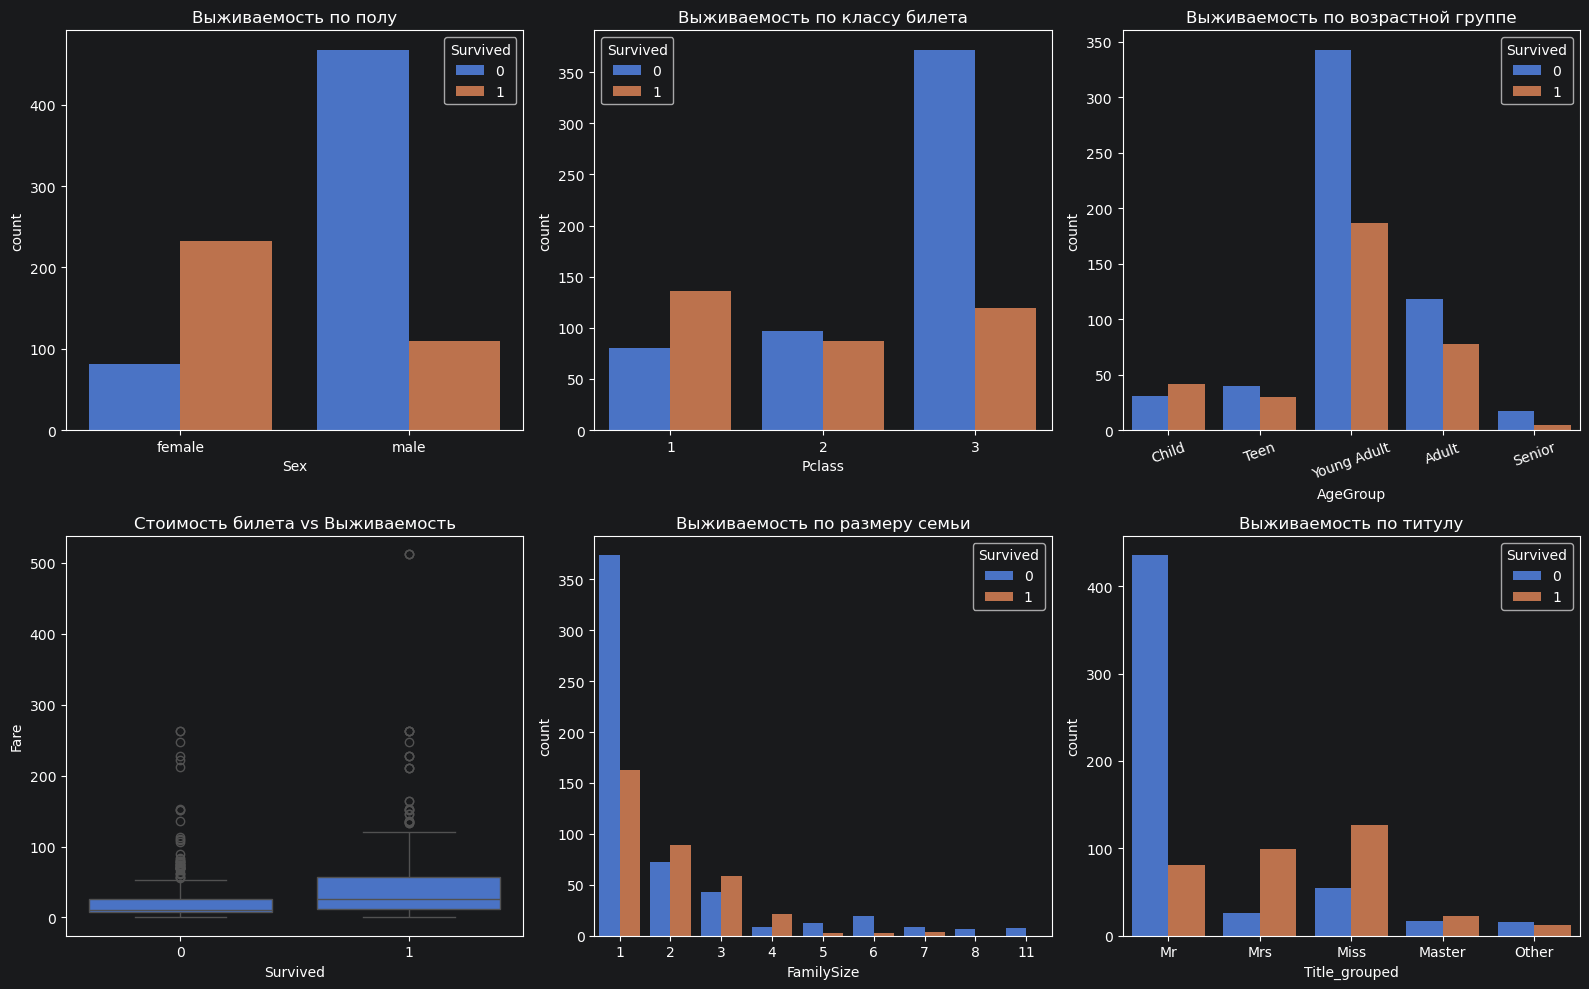

Сводная таблица (доля выживших по классу и полу):


,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Выживаемость по полу
sns.countplot(data=df_train, x='Sex', hue='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Выживаемость по полу')

# Выживаемость по классу
sns.countplot(data=df_train, x='Pclass', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Выживаемость по классу билета')

# Выживаемость по возрастным группам
sns.countplot(data=df_train, x='AgeGroup', hue='Survived', ax=axes[0, 2])
axes[0, 2].set_title('Выживаемость по возрастной группе')
axes[0, 2].tick_params(axis='x', rotation=20)

# Распределение Fare по выжившим/не выжившим
sns.boxplot(data=df_train, x='Survived', y='Fare', ax=axes[1, 0])
axes[1, 0].set_title('Стоимость билета vs Выживаемость')

# Выживаемость по размеру семьи
sns.countplot(data=df_train, x='FamilySize', hue='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Выживаемость по размеру семьи')

# Выживаемость по титулу
sns.countplot(data=df_train, x='Title_grouped', hue='Survived', ax=axes[1, 2])
axes[1, 2].set_title('Выживаемость по титулу')

plt.tight_layout()
plt.show()

# Сводная таблица: Pclass × Sex → доля выживших
print("Сводная таблица (доля выживших по классу и полу):")
df_train['Survived'] = pd.to_numeric(df_train['Survived'], errors='coerce')
pivot = df_train.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean', observed=True)
pivot = pivot.rename_axis(columns=None)
display(pivot)

### 10. Сохранение обработанных выборок в файлы.

In [ ]:
df_train.to_csv('train_processed.csv', index=False)

print("Файл сохранен: train_processed.csv")
print(f"Размер файла: {df_train.shape}")

## Контрольные вопросы.

*   Ответьте на вопросы из методички к 1 лабораторной работе.
*   Ответьте на вопросы из методички ко 2 лабораторной работе.
*   Ответьте на вопросы из методички к 3 лабораторной работе.
